<a href="https://colab.research.google.com/github/aniilkeles/DeepLearningNotes/blob/main/TransferLearning/PyTorch_TransferLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
from tqdm import tqdm # Eğitim sürecini izlemek için kullanacağım ilerleme çubuğu
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report,confusion_matrix

In [2]:
# veri dönüşümü
# 1- klasik dönüşümler => normalizasyon,tensör
# 2- mobilnete uygun input boyutlarının ayarlanması
# 3- data augmentation
transform_train = transforms.Compose([
    transforms.Resize((224,224)), # mobilenet input size yazılır
    transforms.RandomHorizontalFlip(), # görüntüleri yatay çevirerek veri arttırır.
    transforms.RandomRotation(10), # görüntüleri rastgele 10 dereceye kadar döndürür.
    transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1), # renk varyasyonları
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5)) # piksel değerlerini normalize eder.
])

In [3]:
# test veri setine data augmentation yapılmaz.
transform_test = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

100%|██████████| 345M/345M [00:14<00:00, 24.4MB/s]
100%|██████████| 502/502 [00:00<00:00, 620kB/s]
100%|██████████| 15.0k/15.0k [00:00<00:00, 19.7MB/s]


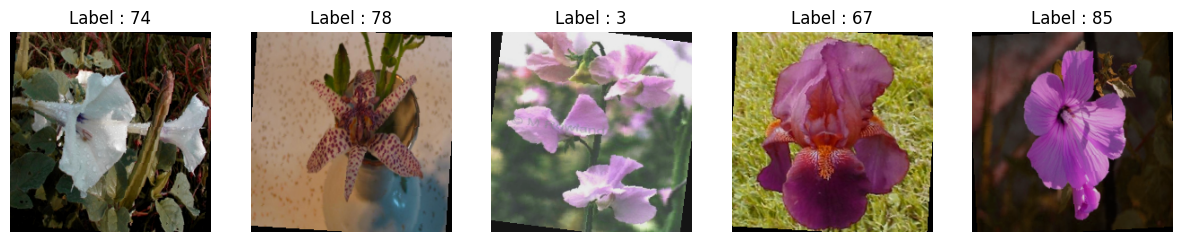

In [4]:
# oxford flowers 102 veri seti
train_dataset = datasets.Flowers102(root="./data",split="train",transform=transform_train,download=True)
test_dataset = datasets.Flowers102(root="./data",split="val",transform=transform_test,download=True)
# rastgele 5 örnek seçimi
indices = torch.randint(len(train_dataset),(5,))
samples = [train_dataset[i] for i in indices]
# görselleştirme
fig,axes = plt.subplots(1,5,figsize=(15,5))
for i,(image,label) in enumerate(samples):
  image = image.numpy().transpose((1,2,0)) # tensörü görüntü formatına dönüştür
  image = (image*0.5)+0.5 # normalizasyonun tersi orjinalleri görüntülemek istiyorsak yapmak zorundayız.
  axes[i].imshow(image)
  axes[i].set_title(f"Label : {label}")
  axes[i].axis("off")
plt.show()

In [12]:
# data loader
train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False)

In [13]:
# mobilenetv2
model = models.mobilenet_v2(pretrained=True) # pretrained => önceden eğitilmiş ağırlıkları kullanır.
# sınıflandırıcı katmanı
num_ftrs = model.classifier[1].in_features # mevcut sınıflandırıcının giriş özelliklerini alır.
model.classifier[1] = nn.Linear(num_ftrs,102) # son katmanı oxford flower 102 için değiştirmiş olduk.
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[1].parameters(),lr=0.001) # normalde model.parameters yazardık ama burda modelimin içerisinde bulunan benim tanımlamış olduğum layerın parametrelerini optimize et demek.
scheduler = optim.lr_scheduler.StepLR(optimizer,step_size=5,gamma=0.1)# belirli aralıklarla rate değişmesini sağlar.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [15]:
# model training
epochs = 3
for epoch in tqdm(range(epochs)):
  model.train()
  running_loss = 0.0
  for images,labels in tqdm(train_loader):
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()
  scheduler.step()
  print(f"Epoch : {epoch+1} , Loss : {running_loss/len(train_loader):.4f}")

 33%|███▎      | 1/3 [02:19<04:38, 139.09s/it]

Epoch : 1 , Loss : 3.2197



 67%|██████▋   | 2/3 [04:41<02:20, 140.77s/it]

Epoch : 2 , Loss : 2.0080



100%|██████████| 3/3 [06:59<00:00, 139.81s/it]

Epoch : 3 , Loss : 1.3877


In [16]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
  for images,labels in tqdm(test_loader):
    outputs = model(images) # prediction return
    _,predicted = torch.max(outputs,1)
    all_preds.extend(predicted.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())


100%|██████████| 128/128 [00:40<00:00,  3.18it/s]


In [17]:
all_preds

[np.int64(85),
 np.int64(85),
 np.int64(0),
 np.int64(0),
 np.int64(85),
 np.int64(85),
 np.int64(85),
 np.int64(40),
 np.int64(0),
 np.int64(85),
 np.int64(6),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(79),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(54),
 np.int64(54),
 np.int64(31),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(3),
 np.int64(79),
 np.int64(56),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(73),
 np.int64(3),
 np.int64(101),
 np.int64(3),
 np.int64(40),
 np.int64(4),
 np.int64(40),
 np.int64(70),
 np.int64(40),
 np.int64(4),
 np.int64(40),
 np.int64(40),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(101),
 np.int64(5),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(

In [18]:
all_preds

[np.int64(85),
 np.int64(85),
 np.int64(0),
 np.int64(0),
 np.int64(85),
 np.int64(85),
 np.int64(85),
 np.int64(40),
 np.int64(0),
 np.int64(85),
 np.int64(6),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(1),
 np.int64(79),
 np.int64(1),
 np.int64(1),
 np.int64(2),
 np.int64(2),
 np.int64(54),
 np.int64(54),
 np.int64(31),
 np.int64(2),
 np.int64(2),
 np.int64(2),
 np.int64(3),
 np.int64(2),
 np.int64(3),
 np.int64(79),
 np.int64(56),
 np.int64(3),
 np.int64(3),
 np.int64(3),
 np.int64(73),
 np.int64(3),
 np.int64(101),
 np.int64(3),
 np.int64(40),
 np.int64(4),
 np.int64(40),
 np.int64(70),
 np.int64(40),
 np.int64(4),
 np.int64(40),
 np.int64(40),
 np.int64(4),
 np.int64(4),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(5),
 np.int64(101),
 np.int64(5),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(6),
 np.int64(

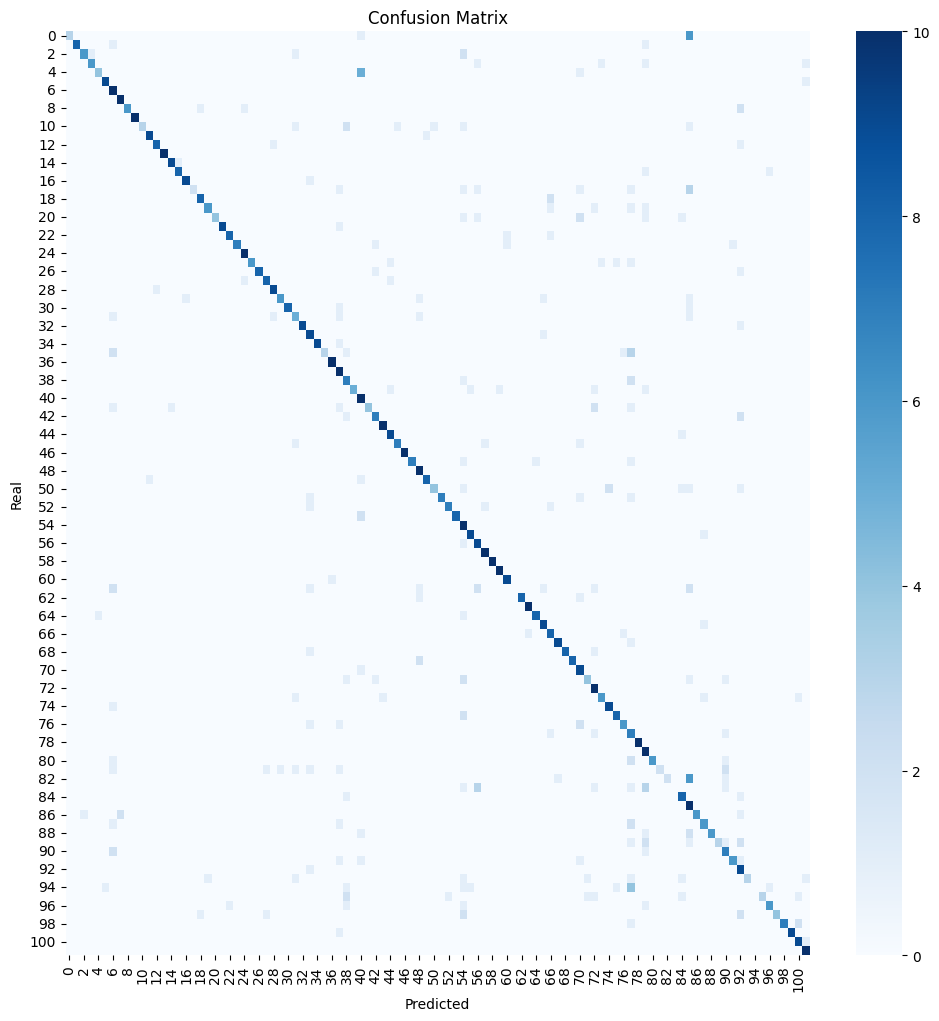

In [20]:
# confusion matrix
cm = confusion_matrix(all_labels,all_preds)
plt.figure(figsize=(12,12))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Real")
plt.title("Confusion Matrix")
plt.show()

In [21]:
print(classification_report(all_labels,all_preds))

              precision    recall  f1-score   support

           0       1.00      0.30      0.46        10
           1       1.00      0.80      0.89        10
           2       0.86      0.60      0.71        10
           3       0.86      0.60      0.71        10
           4       0.80      0.40      0.53        10
           5       0.90      0.90      0.90        10
           6       0.43      1.00      0.61        10
           7       0.83      1.00      0.91        10
           8       1.00      0.60      0.75        10
           9       1.00      1.00      1.00        10
          10       1.00      0.30      0.46        10
          11       0.90      0.90      0.90        10
          12       0.89      0.80      0.84        10
          13       1.00      1.00      1.00        10
          14       0.90      0.90      0.90        10
          15       0.89      0.80      0.84        10
          16       0.90      0.90      0.90        10
          17       1.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
